In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

engine = create_engine("postgresql+psycopg://localhost/props")

def q(sql):
    """Shortcut to run SQL and get a DataFrame."""
    return pd.read_sql(sql, engine)

In [2]:
q("""
SELECT sport_code, COUNT(*) AS games, MIN(game_date), MAX(game_date)
FROM games
GROUP BY sport_code
ORDER BY sport_code;
""")

,sport_code,games,min,max
0,mlb,7631,2023-03-30,2026-05-26
1,nba,2,2026-05-25,2026-05-26
2,nhl,2,2026-05-25,2026-05-26
3,wnba,5,2026-05-25,2026-05-27


In [3]:
q("""
SELECT sport_code, COUNT(*) AS player_games
FROM player_games pg
JOIN games g USING (game_id)
GROUP BY sport_code;
""")

,sport_code,player_games
0,mlb,217890


Total player-games: 153,015
count    153015.000000
mean          0.822377
std           0.867522
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           6.000000
Name: hits, dtype: float64


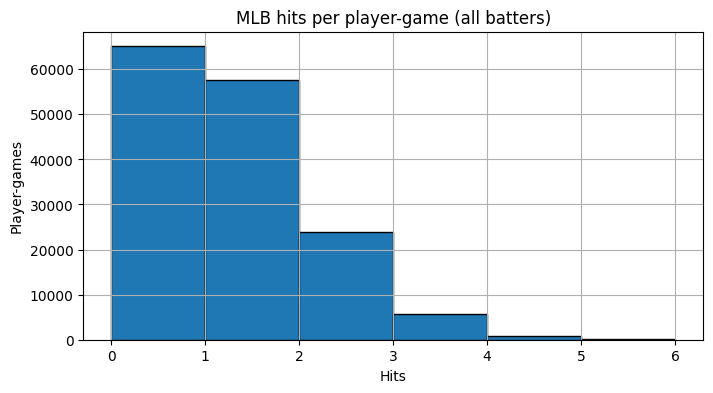

In [4]:
df = q("""
SELECT (pg.stats->>'hits')::int AS hits
FROM player_games pg
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int > 0;
""")
print(f"Total player-games: {len(df):,}")
print(df["hits"].describe())
df["hits"].hist(bins=range(0, 7), edgecolor='black', figsize=(8, 4))
plt.title("MLB hits per player-game (all batters)")
plt.xlabel("Hits")
plt.ylabel("Player-games")
plt.show()

In [5]:
df = q("""
SELECT p.full_name,
       COUNT(*) AS games,
       AVG((pg.stats->>'hits')::int) AS avg_hits,
       AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS over_15_rate
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int >= 3
GROUP BY p.full_name
HAVING COUNT(*) >= 30
ORDER BY over_15_rate DESC
LIMIT 30;
""")
df

,full_name,games,avg_hits,over_15_rate
0,Luis Arraez,459,1.320261,0.379085
1,Ronald Acuña Jr.,305,1.196721,0.370492
2,Roman Anthony,67,1.119403,0.358209
3,Yandy Díaz,426,1.197183,0.356808
4,Xavier Edwards,235,1.187234,0.348936
5,Bo Bichette,371,1.210243,0.345013
6,Daylen Lile,99,1.111111,0.343434
7,Jacob Wilson,147,1.170068,0.340136
8,Trea Turner,447,1.187919,0.337808
9,Jose Altuve,405,1.160494,0.335802


In [6]:
q("""
SELECT p.full_name, pl.sport_code, pl.stat_type, pl.line_value
FROM prop_lines pl
JOIN players p ON p.player_id=pl.player_id
WHERE pl.sportsbook='prizepicks'
  AND pl.line_variant='standard'
  AND pl.sport_code='mlb'
ORDER BY pl.stat_type, p.full_name
LIMIT 30;
""")

,full_name,sport_code,stat_type,line_value
0,Aaron Civale,mlb,earned_runs_allowed,2.5
1,Aaron Civale,mlb,earned_runs_allowed,3.5
2,Braxton Ashcraft,mlb,earned_runs_allowed,0.5
3,Braxton Ashcraft,mlb,earned_runs_allowed,1.5
4,Braxton Ashcraft,mlb,earned_runs_allowed,3.5
5,Emmet Sheehan,mlb,earned_runs_allowed,0.5
6,Emmet Sheehan,mlb,earned_runs_allowed,3.5
7,Emmet Sheehan,mlb,earned_runs_allowed,1.5
8,Griffin Jax,mlb,earned_runs_allowed,1.5
9,Joe Ryan,mlb,earned_runs_allowed,2.5


In [7]:
df = q("""
WITH player_history AS (
    SELECT p.player_id, p.full_name,
           AVG((pg.stats->>'hits')::int) AS avg_hits,
           AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS hist_over_15,
           COUNT(*) AS sample
    FROM player_games pg
    JOIN players p USING (player_id)
    JOIN games g USING (game_id)
    WHERE g.sport_code='mlb'
      AND (pg.stats->>'plate_appearances')::int >= 3
    GROUP BY p.player_id, p.full_name
    HAVING COUNT(*) >= 30
),
current_lines AS (
    SELECT p.player_id, AVG(pl.line_value) AS pp_line
    FROM prop_lines pl
    JOIN players p ON p.player_id=pl.player_id
    WHERE pl.sportsbook='prizepicks'
      AND pl.line_variant='standard'
      AND pl.stat_type='hits'
      AND pl.sport_code='mlb'
    GROUP BY p.player_id
)
SELECT ph.full_name, ph.avg_hits, ph.hist_over_15, ph.sample, cl.pp_line
FROM player_history ph
JOIN current_lines cl USING (player_id)
ORDER BY cl.pp_line DESC, ph.hist_over_15 DESC
LIMIT 50;
""")
df

,full_name,avg_hits,hist_over_15,sample,pp_line
0,Julio Rodríguez,1.104384,0.321503,479,1.5
1,Josh Naylor,1.063927,0.301370,438,1.5
2,J.P. Crawford,0.921615,0.242280,421,1.5
3,Andrew Benintendi,0.939948,0.227154,383,1.5
4,Victor Caratini,0.907407,0.226852,216,1.5
5,Isaac Collins,0.834783,0.200000,115,1.5
6,Kyle Isbel,0.798013,0.192053,302,1.5
7,Kyle Karros,0.720000,0.180000,50,1.5
8,José Fermín,0.673469,0.142857,49,1.5
9,Victor Scott II,0.674699,0.138554,166,1.5


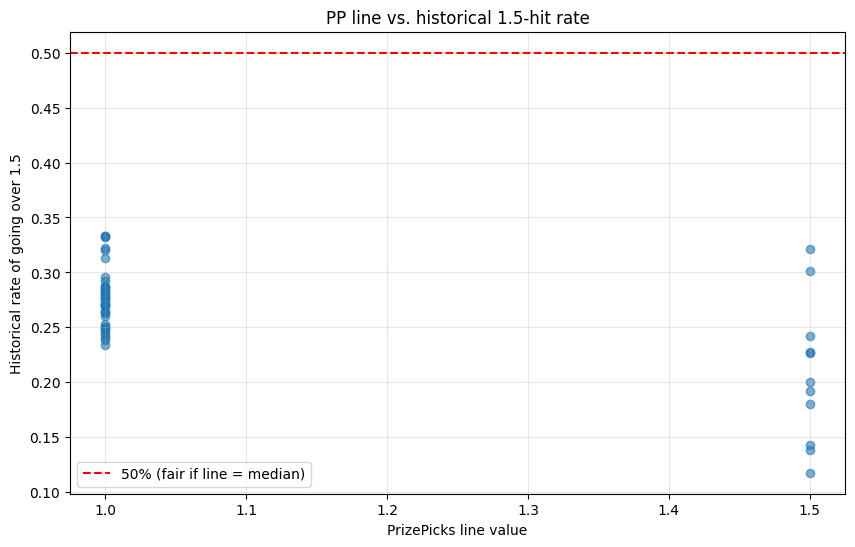

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["pp_line"], df["hist_over_15"], alpha=0.6)
plt.axhline(0.5, color='red', linestyle='--', label='50% (fair if line = median)')
plt.xlabel("PrizePicks line value")
plt.ylabel("Historical rate of going over 1.5")
plt.title("PP line vs. historical 1.5-hit rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
df_k = q("""
SELECT p.full_name,
       COUNT(*) AS starts,
       AVG((pg.stats->>'strikeouts_pitcher')::int) AS avg_k,
       AVG((pg.stats->>'outs_recorded')::int / 3.0) AS avg_ip
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'batters_faced')::int >= 15
GROUP BY p.full_name
HAVING COUNT(*) >= 15
ORDER BY avg_k DESC
LIMIT 25;
""")
df_k

,full_name,starts,avg_k,avg_ip
0,Tarik Skubal,81,7.567901,6.164609
1,Garrett Crochet,60,7.533333,5.794444
2,Tyler Glasnow,61,7.491803,5.814208
3,Spencer Strider,61,7.409836,5.661202
4,Chris Sale,72,7.375000,5.819444
5,Blake Snell,66,7.318182,5.666667
6,Shohei Ohtani,33,7.272727,5.747475
7,Zack Wheeler,96,7.208333,6.197917
8,Cole Ragans,58,7.206897,5.660920
9,Paul Skenes,57,7.052632,5.906433


In [10]:
# === Today's logged picks ===
picks = q("""
SELECT p.full_name, pk.stat_type, pl.line_value,
       pk.direction, pk.model_prob, pk.edge,
       pk.actual_value, pk.leg_result,
       pk.picked_at::date AS picked_date
FROM picks pk
JOIN players p USING (player_id)
JOIN prop_lines pl ON pl.line_id = pk.line_id
ORDER BY pk.picked_at DESC;
""")
picks

,full_name,stat_type,line_value,direction,model_prob,edge,actual_value,leg_result,picked_date
0,Aaron Civale,strikeouts_pitcher,4.0,under,0.5703,0.0703,None,None,2026-05-25
1,Emmet Sheehan,strikeouts_pitcher,6.0,under,0.8005,0.3005,None,None,2026-05-25


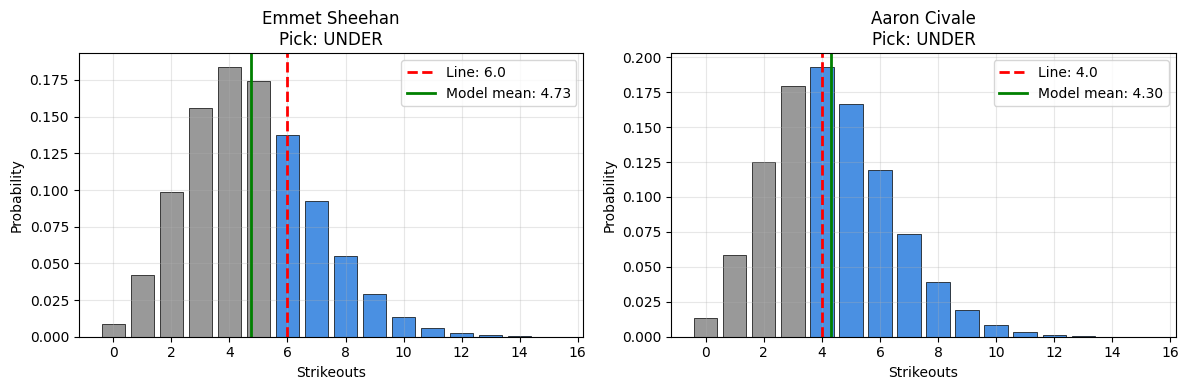

In [11]:
# === Predicted Poisson distributions for tonight's picks ===
import numpy as np
from scipy import stats as scipy_stats

picks_df = q("""
SELECT p.full_name,
       pr.predicted_mean,
       pl.line_value,
       pk.direction
FROM picks pk
JOIN players p USING (player_id)
JOIN prop_lines pl ON pl.line_id = pk.line_id
JOIN predictions pr ON pr.prediction_id = pk.prediction_id
ORDER BY pk.edge DESC;
""")

fig, axes = plt.subplots(1, len(picks_df), figsize=(6 * len(picks_df), 4))
if len(picks_df) == 1:
    axes = [axes]

k_range = np.arange(0, 16)
for ax, (_, row) in zip(axes, picks_df.iterrows()):
    lam = float(row["predicted_mean"])
    line = float(row["line_value"])
    probs = scipy_stats.poisson.pmf(k_range, lam)
    
    colors = ['#999' if k < line else '#4a90e2' for k in k_range]
    ax.bar(k_range, probs, color=colors, edgecolor='black', linewidth=0.5)
    ax.axvline(line, color='red', linestyle='--', linewidth=2, 
               label=f'Line: {line}')
    ax.axvline(lam, color='green', linestyle='-', linewidth=2,
               label=f'Model mean: {lam:.2f}')
    ax.set_xlabel('Strikeouts')
    ax.set_ylabel('Probability')
    ax.set_title(f"{row['full_name']}\nPick: {row['direction'].upper()}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()